# A day of BTCUSDT order book on a free CandleFeed key

The 1st of every month is a free L2 sample day on every CandleFeed plan, including Free (up to 10 GiB of new files a month). This notebook takes the 2026-10-01 sample for Binance USD-M `BTCUSDT`, downloads it, rebuilds the order book from the raw depth diffs, and looks at the spread over the day, the book around the day's sharpest minute, and the depth on each side at that moment.

You need a CandleFeed API key in `CANDLEFEED_API_KEY`. Free keys are at https://candlefeed.ai/signup?utm_source=notebook&utm_medium=example

The download is 382 MB, which took 73 seconds on our last test run. Everything after it covers the whole day and took 58 seconds on our test machine.

In [1]:
# pip install "candlefeed[l2]>=0.3.1" matplotlib
import hashlib
import json
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from candlefeed import CandleFeed, TierRestrictedError
from candlefeed.l2book import L2Book

SYMBOL, DAY = "BTCUSDT", "2026-10-01"
DATA = Path(os.environ.get("CANDLEFEED_DATA_DIR", "candlefeed_data"))
cf = CandleFeed()  # reads CANDLEFEED_API_KEY

## 1. Download the day

`download_l2` asks the API for the day's file list (with 15-minute download links), streams each file to a `.part` file, and renames it into place only if its size and SHA-256 match what the API listed. Run it again and files already on disk are re-hashed and skipped.

In [2]:
t0 = time.time()
got = cf.download_l2("book", SYMBOL, DAY, None, DATA)
print(f"{len(got['downloaded'])} files downloaded, {len(got['skipped'])} already on disk, "
      f"{got['bytes'] / 1e6:,.0f} MB in {time.time() - t0:.0f} s; missing days: {got['missing'] or 'none'}")

26 files downloaded, 0 already on disk, 382 MB in 73 s; missing days: none


The client already checked every file. Here's the same check done by hand, against a fresh listing, so you can see what it compares:

In [3]:
listing = cf.l2_files("book", SYMBOL, DAY)
day_dir = DATA / "book" / "binance" / SYMBOL / DAY
rows = []
for f in listing["days"][0]["files"]:
    local = day_dir / f["name"]
    rows.append({"file": f["name"], "MB": round(f["size"] / 1e6, 1), "rows": f.get("rows"),
                 "listed sha256": f["sha256"][:16] + "...",
                 "size ok": local.stat().st_size == f["size"],
                 "sha256 ok": hashlib.sha256(local.read_bytes()).hexdigest() == f["sha256"]})
files = pd.DataFrame(rows).astype({"rows": "Int64"})
usage = listing.get("usage")
print(f"{files['size ok'].sum()}/{len(files)} sizes and {files['sha256 ok'].sum()}/{len(files)} SHA-256 hashes match; "
      f"{files['MB'].sum():,.0f} MB in total")
if not usage:
    print("This listing carries no usage figures.")
elif usage["limit_bytes"] is None:  # Pro and Enterprise: no monthly allowance, only the daily link limit
    print(f"Full-archive plan: no monthly allowance. Links issued today: {usage['issued_today_bytes'] / 2**30:.2f} "
          f"of {usage['daily_limit_bytes'] / 2**30:,.0f} GiB")
else:
    print(f"Sample allowance used this month: {usage['used_bytes'] / 2**30:.2f} of {usage['limit_bytes'] / 2**30:.0f} GiB "
          f"(resets {usage['resets_on']})")
pd.concat([files.head(3), files.tail(3)])

26/26 sizes and 26/26 SHA-256 hashes match; 382 MB in total
Sample allowance used this month: 0.78 of 10 GiB (resets 2026-11-01)


,file,MB,rows,listed sha256,size ok,sha256 ok
0,depth/00.parquet,12.0,3334025,3c610761758a6c76...,True,True
1,depth/01.parquet,12.2,3341487,b27662eb6d87c885...,True,True
2,depth/02.parquet,12.8,3491705,81aed47eb4f48343...,True,True
23,depth/23.parquet,9.6,2550900,2def631acf047197...,True,True
24,snapshot.parquet,1.6,570000,a63dd4d89108f2ef...,True,True
25,manifest.json,0.0,<NA>,21351b43585bce72...,True,True


## 2. What's in the folder

A `book` day is three kinds of file:

- `depth/00.parquet` through `depth/23.parquet` hold every event from Binance's diff-depth stream, one file per UTC hour and one row per changed price level, with Binance's update IDs so the chain can be checked for breaks.
- `snapshot.parquet` holds REST snapshots of the top 1,000 levels per side, taken about every 5 minutes. They're the anchors the book is rebuilt from.
- `manifest.json` records what went into the day: which of the three capture nodes each stretch came from, coverage, gaps and QC warnings.

In [4]:
manifest = json.loads((day_dir / "manifest.json").read_text())
c = manifest["canonical"]
print(f"{c['events']:,} diff events, {c['rows']:,} price-level rows, {c['snapshots_kept']} snapshots kept")
print(f"first event {c['first_event']}, last {c['last_event']}")
print(f"coverage {c['coverage_pct']}%, unbroken stretches: {c['segments']}, gaps: {len(manifest['gaps'])}")
print(f"capture nodes: {', '.join(manifest['node_priority'])} (base: {manifest['base_node']})")

846,944 diff events, 107,227,485 price-level rows, 285 snapshots kept
first event 2026-10-01T00:00:00.036Z, last 2026-10-01T23:59:59.928Z
coverage 100.0%, unbroken stretches: 1, gaps: 0
capture nodes: tokyo, tokyo-vultr, singapore (base: tokyo)


## 3. Rebuild the book and sample the spread

`L2Book` indexes the day, anchors on the first usable snapshot, then applies the diffs. Sampling it every second gives the best bid, best ask and spread at each of the day's 86,400 seconds.

In [5]:
t0 = time.time()
book = L2Book.load(DATA, SYMBOL, DAY)
print(book, f"indexed in {time.time() - t0:.1f} s")

t0 = time.time()
spread = book.spread_series("1s")
print(f"{len(spread):,} one-second samples in {time.time() - t0:.0f} s")

ok = spread.dropna(subset=["mid"])
tick = ok["spread"].min()
widest = ok["spread"].idxmax()
print(f"Book available in {len(ok):,} of {len(spread):,} seconds ({len(ok) / len(spread):.1%}); "
      "the figures below use those seconds only")
print(f"Mid: low {ok['mid'].min():,.2f} at {ok['mid'].idxmin():%H:%M:%S}, "
      f"high {ok['mid'].max():,.2f} at {ok['mid'].idxmax():%H:%M:%S} UTC")
print(f"Spread: median {ok['spread'].median():.2f} USDT ({ok['spread_bps'].median():.4f} bps), "
      f"one tick ({tick:.2f}) in {(ok['spread'] <= tick + 1e-9).mean():.1%} of seconds, "
      f"99th percentile {ok['spread'].quantile(0.99):.2f}, widest {ok['spread'].max():.2f} "
      f"({ok['spread_bps'].max():.2f} bps) at {widest:%H:%M:%S} UTC")

L2Book(2026-10-01, events=846,944, snapshots=285, segments=1) indexed in 0.5 s


86,400 one-second samples in 20 s
Book available in 80,840 of 86,400 seconds (93.6%); the figures below use those seconds only
Mid: low 83,142.85 at 08:35:46, high 85,240.85 at 18:39:31 UTC
Spread: median 0.10 USDT (0.0119 bps), one tick (0.10) in 99.9% of seconds, 99th percentile 0.10, widest 13.20 (1.57 bps) at 15:56:25 UTC


On 2026-10-01 the BTCUSDT perp sat at one tick (0.10 USDT, about 0.012 bps at 83,000 to 85,000) in 99.9% of the seconds that had a book, and its 99th percentile was still one tick. The widest moment was 13.20 USDT (1.57 bps) at 15:56:25 UTC. The mid ran from 83,142.85 at 08:35:46 to 85,240.85 at 18:39:31.

Those spread and price figures come from the seconds that had a book, 93.6% of the day. The other 6.4% (5,560 seconds) had none. Six of them are the first seconds of the day, before the first usable snapshot anchors the book at 00:00:05.646. The other 5,554 are moments when price had moved past the edge of the last snapshot (section 4 explains why). The mid line below is drawn from the 1-second samples, so every unavailable second shows as a break. The spread panel aggregates each minute over its available seconds only, on a log scale because almost every minute is flat at one tick.

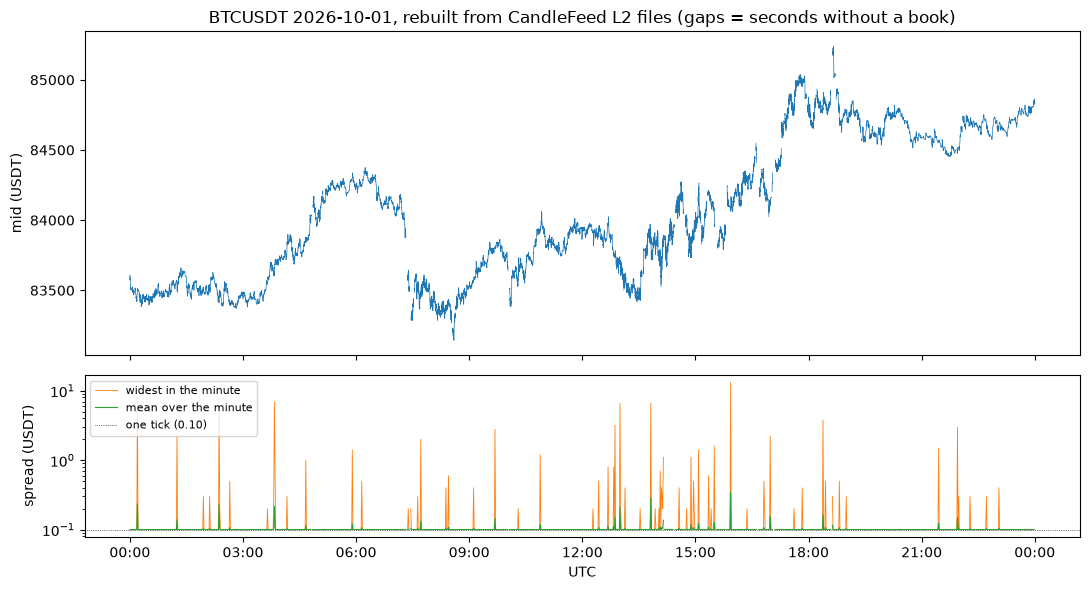

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
ax1.plot(spread.index, spread["mid"], lw=0.5)  # 1-second samples; NaN where there's no book, drawn as breaks
ax1.set_ylabel("mid (USDT)")
ax1.set_title(f"{SYMBOL} {DAY}, rebuilt from CandleFeed L2 files (gaps = seconds without a book)")
per_min = spread["spread"].resample("1min")  # each minute over its available seconds only
ax2.plot(per_min.max().index, per_min.max(), lw=0.6, color="C1", label="widest in the minute")
ax2.plot(per_min.mean().index, per_min.mean(), lw=0.8, color="C2", label="mean over the minute")
ax2.axhline(tick, color="k", lw=0.5, ls=":", label=f"one tick ({tick:.2f})")
ax2.set_yscale("log")
ax2.set_ylabel("spread (USDT)")
ax2.set_xlabel("UTC")
ax2.legend(fontsize=8, loc="upper left")
ax2.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%H:%M"))
fig.tight_layout()

## 4. The day's biggest one-minute move

`biggest_move` compares the mid at consecutive minute marks (hh:mm:00) and only counts minutes with a usable book at both ends on the same unbroken stretch, so a jump across a gap can't pass for a move.

In [7]:
move = book.biggest_move()
t_before, t_after = move["minute_start"], move["minute_end"]
print(f"{move['bps']:+.1f} bps from {t_before:%H:%M} to {t_after:%H:%M} UTC: "
      f"mid {move['from_mid']:,.2f} -> {move['to_mid']:,.2f} ({move['to_mid'] - move['from_mid']:+,.2f} USDT), "
      f"out of {move['eligible_minutes']:,} eligible minutes")

before, after = book.book_at(t_before, levels=5), book.book_at(t_after, levels=5)

def ladder(view):
    asks = view.asks[["price", "qty"]].iloc[::-1].assign(side="ask")
    bids = view.bids[["price", "qty"]].assign(side="bid")
    return pd.concat([asks, bids], ignore_index=True)[["side", "price", "qty"]]

pd.concat({f"{t_before:%H:%M:%S} (before)": ladder(before), f"{t_after:%H:%M:%S} (after)": ladder(after)}, axis=1)

-20.0 bps from 14:00 to 14:01 UTC: mid 83,905.85 -> 83,737.75 (-168.10 USDT), out of 1,307 eligible minutes


14:00:00 (before)                  14:01:00 (after)                
               side    price     qty             side    price    qty
0               ask  83907.5   0.001              ask  83739.8  0.001
1               ask  83907.4   0.415              ask  83739.6  0.002
2               ask  83906.9   0.001              ask  83739.2  0.024
3               ask  83906.0   0.001              ask  83737.9  0.002
4               ask  83905.9  11.645              ask  83737.8  0.581
5               bid  83905.8   0.371              bid  83737.7  5.605
6               bid  83905.5   0.007              bid  83737.5  0.001
7               bid  83905.4   0.002              bid  83737.3  0.003
8               bid  83904.8   0.001              bid  83737.2  0.027
9               bid  83904.1   0.001              bid  83737.0  0.037

Depth within 5, 10 and 25 bps of the mid, in BTC and in USDT, at both ends of that minute. The `complete` columns say whether the band stays inside the snapshot's known window; a False there means the number is a lower bound.

In [8]:
bands = (5, 10, 25)
depth = pd.concat({f"{t_before:%H:%M}": book.depth_at(t_before, bps=bands),
                   f"{t_after:%H:%M}": book.depth_at(t_after, bps=bands)}, names=["time"])
depth[["bid_qty", "ask_qty", "bid_notional", "ask_notional", "bid_complete", "ask_complete"]].round(2)

bid_qty  ask_qty  bid_notional  ask_notional  bid_complete  \
time  bps                                                                
14:00 5.0     43.34   151.06    3635736.04   12679444.71          True   
      10.0   137.54   290.06   11533613.02   24349800.15          True   
      25.0   426.08   707.48   35702606.25   59435052.71         False   
14:01 5.0     57.62    65.67    4823897.52    5501176.71         False   
      10.0   211.29   151.18   17681923.49   12667048.52         False   
      25.0   621.60   544.64   51981449.39   45674884.65         False   

            ask_complete  
time  bps                 
14:00 5.0           True  
      10.0         False  
      25.0         False  
14:01 5.0           True  
      10.0          True  
      25.0          True

Right before the drop, at 14:00:00, the book within 5 bps of the mid (about 42 USDT either side) held 43.34 BTC of bids against 151.06 BTC of asks, about 3.5 to 1 on the ask side, and both numbers are complete. A minute later the mid was 168.10 USDT lower. At 14:01 the asks within 5 bps had thinned to 65.67 BTC. Every bid figure at 14:01 is flagged incomplete. The 14:01 book still rests on the same snapshot as 14:00, whose known bids stop at 83,712.0, only 25.7 USDT under the new best bid of 83,737.7, so each bid band reaches below that floor, where levels the diffs haven't touched since aren't known. It stays a lower bound until the next snapshot lands.

14:00:00: known levels run from 83,712.0 to 83,984.5; 1159 bid and 585 ask levels inside
14:01:00: known levels run from 83,712.0 to 83,984.5; 189 bid and 1533 ask levels inside


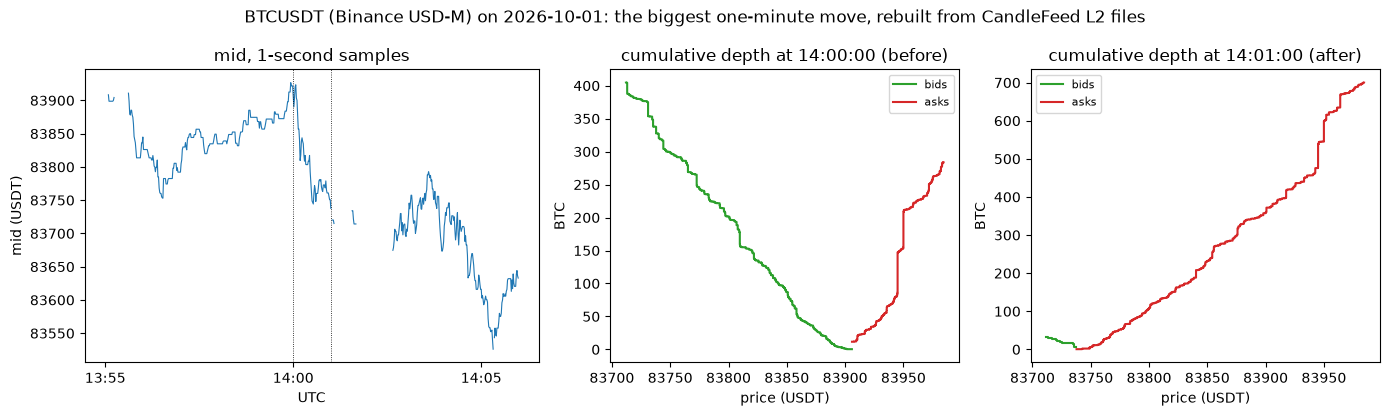

In [9]:
around = book.spread_series("1s", t_before - pd.Timedelta(minutes=5), t_after + pd.Timedelta(minutes=5))

def cumulative(view):
    bids = view.bids[["price", "qty"]].assign(cum=lambda d: d["qty"].cumsum())
    asks = view.asks[["price", "qty"]].assign(cum=lambda d: d["qty"].cumsum())
    return bids, asks

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), gridspec_kw={"width_ratios": [1.3, 1, 1]})
axes[0].plot(around.index, around["mid"], lw=0.8)
for t in (t_before, t_after):
    axes[0].axvline(t, color="k", lw=0.6, ls=":")
axes[0].set_title("mid, 1-second samples")
axes[0].set_ylabel("mid (USDT)")
axes[0].set_xlabel("UTC")
axes[0].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%H:%M"))
axes[0].ticklabel_format(axis="y", useOffset=False, style="plain")
for ax, (label, t) in zip(axes[1:], (("before", t_before), ("after", t_after))):
    view = book.book_at(t, levels=None)
    bids, asks = cumulative(view)
    print(f"{t:%H:%M:%S}: known levels run from {view.bid_window_floor:,.1f} to {view.ask_window_ceiling:,.1f}; "
          f"{len(bids)} bid and {len(asks)} ask levels inside")
    ax.step(bids["price"], bids["cum"], where="post", color="C2", label="bids")
    ax.step(asks["price"], asks["cum"], where="post", color="C3", label="asks")
    ax.set_title(f"cumulative depth at {t:%H:%M:%S} ({label})")
    ax.set_xlabel("price (USDT)")
    ax.set_ylabel("BTC")
    ax.ticklabel_format(axis="x", useOffset=False, style="plain")
    ax.legend(fontsize=8)
fig.suptitle(f"{SYMBOL} (Binance USD-M) on {DAY}: the biggest one-minute move, rebuilt from CandleFeed L2 files")
fig.tight_layout()

The depth charts only draw levels inside the anchor snapshot's 1,000-level window, because only those are known exactly. That's the main reason seconds in section 3 have no book: when price runs past the edge of the last snapshot, one side's best level is unknown until the next snapshot lands, and `L2Book` returns nothing rather than a guess. The only other cause on this day is the first six seconds, before the first usable snapshot anchors the book.

## 5. Gaps, coverage and other days

The gap ledger at `/v1/l2/gaps` is public and lists every stretch on a published day that none of the three capture nodes recorded, with the reason. `/v1/l2/coverage` lists the published days per symbol.

In [10]:
gaps = cf.l2_gaps("book", SYMBOL, DAY, DAY)
print(f"Gaps on {DAY}: {len(gaps['gaps'])} (capture nodes: {', '.join(gaps['node_labels'])})")
cov = cf.l2_coverage("book")["datasets"]["book"]
btc = cov[SYMBOL]
print(f"{len(cov)} symbols published; {SYMBOL} from {btc['first_day']} to {btc['last_day']} "
      f"({btc['days']} days, {len(btc['missing_days'])} missing)")

try:
    cf.l2_files("book", SYMBOL, "2026-10-02")
except TierRestrictedError as e:
    print(f"2026-10-02 on this key: {e}")

Gaps on 2026-10-01: 0 (capture nodes: tokyo, singapore, tokyo-vultr)
25 symbols published; BTCUSDT from 2026-06-04 to 2026-10-04 (123 days, 0 missing)


2026-10-02 on this key: [HTTP 403 tier_restricted] Order book depth for 2026-10-02 requires the Pro plan. Your plan (Free) includes free sample days (the 1st of each month). Upgrade at https://candlefeed.ai/pricing


Every day other than the 1st needs the Pro plan; on a free key the API refuses it with the 403 above, before any download link is issued. The 1st of next month will be free too. The same code works for any of the 25 published symbols (change `SYMBOL`), and `download_l2("trades", ...)` fetches a day's raw tick trades into the same folder layout.